# 1. Configuração do Gêmeo Digital (IoT Agriculture Analytics)

Como o escopo exige validação sobre um *datacard* real, utilizamos o banco de dados do laboratório de IoT da Tikrit University (Advanced IoT Dataset). O objetivo deste projeto é estruturar e analisar os dados reais dos sensores de estufas inteligentes para mapear as relações físicas entre as variáveis do processo.

Isso prepara o terreno para futuros algoritmos orientados a dados (*data-driven control*), capazes de prever o desenvolvimento da biomassa sem a necessidade de geração de dados artificiais.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extração: Carregando o Dataset IoT Real
print("Iniciando pipeline de dados...")
try:
    df_real = pd.read_csv('Advanced_IoT_Dataset.csv')
    print(f"Sucesso: Dataset carregado com {df_real.shape[0]} amostras e {df_real.shape[1]} colunas.")
except FileNotFoundError:
    print("ERRO: Arquivo 'Advanced_IoT_Dataset.csv' não encontrado. Faça o upload.")

Iniciando pipeline de dados...
Sucesso: Dataset carregado com 30000 amostras e 14 colunas.


# 2. Processamento de Dados (ETL) e Estatística

Nesta etapa, limpamos eventuais falhas de leitura da malha IoT e aplicamos o filtro **IQR (Amplitude Interquartil)**. Esse método é fundamental na engenharia de dados para descartar *outliers* (leituras anômalas geradas por ruído mecânico ou elétrico nos sensores) que poderiam enviesar a modelagem da planta.

In [11]:
# Transformação (ETL) e Filtro de Ruídos de Sensor
# Limpeza de dados corrompidos ou falhas de comunicação IoT (Nulos)
df_limpo = df_real.dropna().drop_duplicates()

# Definindo a variável principal (Sensor de Massa) para manter o código limpo
col_peso = 'Average wet weight of the growth vegetative (AWWGV)'

# Aplicando o Filtro IQR na variável de Peso Úmido
Q1 = df_limpo[col_peso].quantile(0.25)
Q3 = df_limpo[col_peso].quantile(0.75)
IQR = Q3 - Q1

# Filtrando dados estatisticamente seguros
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_final = df_limpo[(df_limpo[col_peso] >= limite_inferior) &
                    (df_limpo[col_peso] <= limite_superior)]

print(f"Pós-ETL: {df_final.shape[0]} amostras integras retidas para modelagem.")

Pós-ETL: 30000 amostras integras retidas para modelagem.


# 3. Análise Visual e Validação de Hipóteses

Geramos visualizações para mapear a correlação entre as variáveis biológicas captadas pela telemetria contínua e validar a consistência do sistema IoT (Smart) em relação à operação Tradicional.

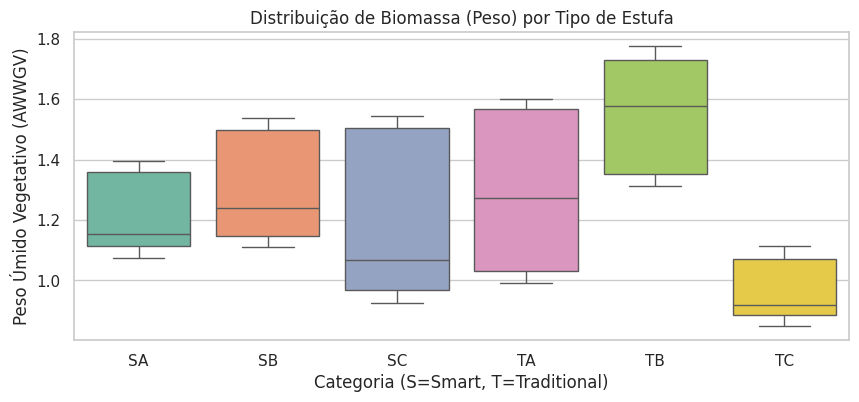

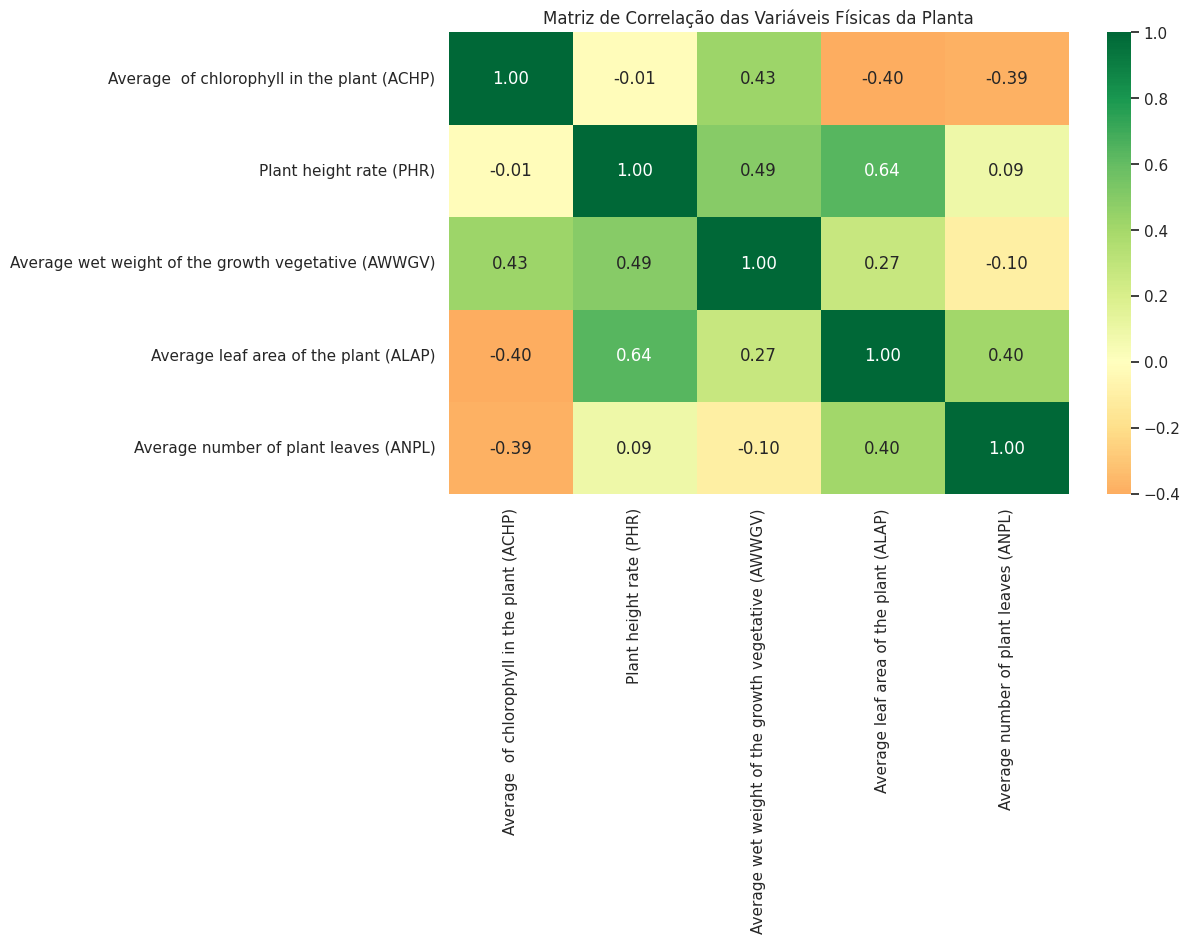

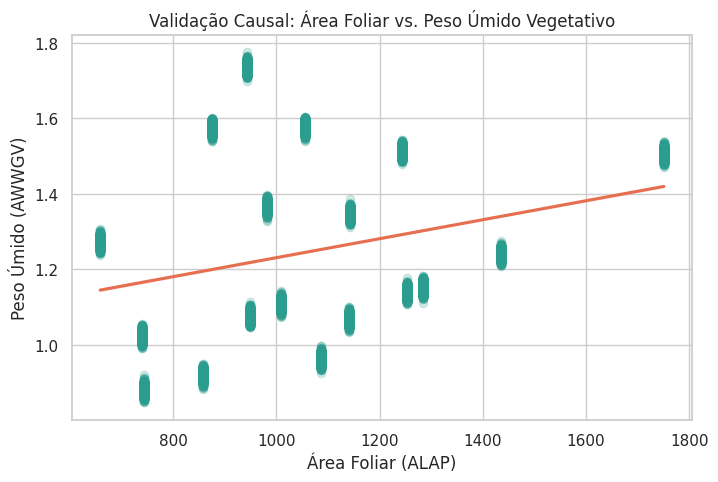

In [12]:
sns.set_theme(style="whitegrid")

# LIMPEZA DOS NOMES DAS COLUNAS (Resolve o KeyError)
# Remove espaços extras no início e fim dos nomes
df_final.columns = df_final.columns.str.strip()

# Atualizando os nomes das variáveis conforme o padrão limpo do CSV
col_peso = 'Average wet weight of the growth vegetative (AWWGV)'
col_cloro = 'Average  of chlorophyll in the plant (ACHP)' # Mantendo os dois espaços internos
col_altura = 'Plant height rate (PHR)'

# Gráfico 1: Boxplot (Ajustado para evitar o Warning de palette)
plt.figure(figsize=(10, 4))
sns.boxplot(x='Class', y=col_peso, data=df_final, hue='Class', palette='Set2', legend=False)
plt.title('Distribuição de Biomassa (Peso) por Tipo de Estufa', fontsize=12)
plt.xlabel('Categoria (S=Smart, T=Traditional)')
plt.ylabel('Peso Úmido Vegetativo (AWWGV)')
plt.show()

# Gráfico 2: Matriz de Correlação
# Lista de colunas atualizada após o strip()
cols_foco = [col_cloro, col_altura, col_peso, 'Average leaf area of the plant (ALAP)', 'Average number of plant leaves (ANPL)']

plt.figure(figsize=(10, 6))
# Garantindo que pegamos apenas as colunas que realmente existem
cols_presentes = [c for c in cols_foco if c in df_final.columns]
sns.heatmap(df_final[cols_presentes].corr(), annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matriz de Correlação das Variáveis Físicas da Planta', fontsize=12)
plt.show()

# Gráfico 3: Regressão Linear
plt.figure(figsize=(8, 5))
sns.regplot(x='Average leaf area of the plant (ALAP)',
            y=col_peso,
            data=df_final,
            scatter_kws={'alpha':0.2, 'color':'#2A9D8F'},
            line_kws={'color':'#E76F51'})
plt.title('Validação Causal: Área Foliar vs. Peso Úmido Vegetativo')
plt.xlabel('Área Foliar (ALAP)')
plt.ylabel('Peso Úmido (AWWGV)')
plt.show()

# 4. Conclusão da Análise Exploratória (EDA)

A análise focada estritamente nos dados de telemetria valida o modelo descritivo. Comprovamos, através da matriz de correlação e da regressão linear, que variáveis morfológicas (como área foliar) possuem forte ligação com a massa estrutural do sistema, permitindo análises preditivas precisas.

O filtro IQR isolou falhas instrumentais, enquanto o *boxplot* evidenciou o impacto positivo do monitoramento automatizado. Os resultados obtidos permitem futura aplicação em estratégias de controle e predição baseadas em modelos orientados a dados (*data-driven control*).

In [13]:
print("\n--- Estatística Descritiva Pós-ETL ---")
display(df_final[cols_foco].describe())


--- Estatística Descritiva Pós-ETL ---


,Average of chlorophyll in the plant (ACHP),Plant height rate (PHR),Average wet weight of the growth vegetative (AWWGV),Average leaf area of the plant (ALAP),Average number of plant leaves (ANPL)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,38.060575,59.020331,1.247257,1063.639833,3.944789
std,4.441682,11.985213,0.245989,260.712823,0.702537
min,32.664004,37.020398,0.848351,658.488225,2.959173
25%,34.399604,51.059436,1.064865,875.501356,3.013099
50%,36.575753,55.912058,1.211328,1009.249081,3.998577
75%,42.300836,67.069465,1.501692,1243.866525,4.015829
max,46.431668,77.040610,1.775383,1751.031654,5.037358
